In [ ]:
As a culminating project, you'll be working with a dataset from ABC company,
consisting of 458 rows and 9 columns. The company requires a comprehensive
report detailing information about their employees across various teams. Your
tasks include preprocessing the dataset, analyzing the data, and presenting your
findings graphically. Here's a breakdown of what you need to do:
Preprocessing:
● Correct the data in the "height" column by replacing it with random
numbers between 150 and 180. Ensure data consistency and integrity
before proceeding with analysis. (1 mark)
Analysis Tasks:
● Determine the distribution of employees across each team and calculate
the percentage split relative to the total number of employees. (2 marks)
● Segregate employees based on their positions within the company. (2
marks)
● Identify the predominant age group among employees. (2 marks)
● Discover which team and position have the highest salary expenditure. (2
marks)
● Investigate if there's any correlation between age and salary, and
represent it visually. (2 marks)
Graphical Representation:
● For each of the five analysis tasks above, create appropriate visualizations
to present your findings effectively. (5x2 = 10 marks)
● Data Story: Provide insights gained from the analysis, highlighting key
trends, patterns, and correlations within the dataset. (3 marks)
● Timely Submission: Ensure timely submission of your project to earn an
additional mark. (1 mark)
Total Marks : 25
By completing these tasks, you'll not only demonstrate your proficiency in Python
programming but also your ability to analyze and communicate insights from

real-world data. Download the dataset from this link. (Please find the
attachment):
https://docs.google.com/spreadsheets/d/1aDiNQMStFPyY7mJEgt2sIAApFr
G2uE19/edit?usp=drive_link&ouid=110420460158510759989&rtpof=true&sd
=true
● To submit the project:
● Create a repository on your GitHub account.
● Write a comprehensive overview of the project in the README file,
summarizing the preprocessing steps, analysis tasks, graphical
representations, insights gained, and any additional information.
● Upload a well-organized Jupyter Notebook file containing the code for the
project, ensuring proper formatting and documentation.
● Include the dataset in the repository.
● Submit the link to your repository in the designated section on the app.
Best of luck, and feel free to reach out if you have any questions or need
assistance along the way!

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [8]:
df = pd.read_csv("ABCCompany2.csv")

In [9]:
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,06-Feb,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,06-Jun,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,06-May,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,06-May,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,06-Oct,231,NaN,5000000.0


In [10]:
df.columns = [c.strip() for c in df.columns]

if 'Height' in df.columns:
    df['Height'] = np.random.randint(150, 181, size=len(df))  # inclusive 150-180
else:
    df['Height'] = np.random.randint(150, 181, size=len(df))


In [11]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

if 'Age' in df.columns:
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
if 'Salary' in df.columns:
    df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')


In [12]:
critical_cols = [c for c in ['Team','Position','Age','Salary'] if c in df.columns]
before = len(df)
if critical_cols:
    df = df.dropna(subset=critical_cols)

In [13]:
print(f"Dropped {before - len(df)} rows with missing critical fields. New shape: {df.shape}")

Dropped 11 rows with missing critical fields. New shape: (447, 9)


In [14]:
cleaned_csv = "employee_data_cleaned.csv"
df.to_csv(cleaned_csv, index=False)
print("Saved cleaned dataset to:", cleaned_csv)

Saved cleaned dataset to: employee_data_cleaned.csv


In [16]:
sns.set(style="whitegrid")

In [17]:
def save_plot(fig, fname):
    path = os.path.join(PLOT_DIR, fname)
    fig.tight_layout()
    fig.savefig(path, dpi=150)
    print("Saved:", path)

# Distribution of employees across each team + percentage split (2 marks)

Team counts: Team
New Orleans Pelicans     19
New York Knicks          16
Milwaukee Bucks          16
Utah Jazz                16
Golden State Warriors    15
Brooklyn Nets            15
Chicago Bulls            15
Detroit Pistons          15
Phoenix Suns             15
Sacramento Kings         15
Name: count, dtype: int64
Team % split: Team
New Orleans Pelicans     4.25
New York Knicks          3.58
Milwaukee Bucks          3.58
Utah Jazz                3.58
Golden State Warriors    3.36
Brooklyn Nets            3.36
Chicago Bulls            3.36
Detroit Pistons          3.36
Phoenix Suns             3.36
Sacramento Kings         3.36
Name: count, dtype: float64


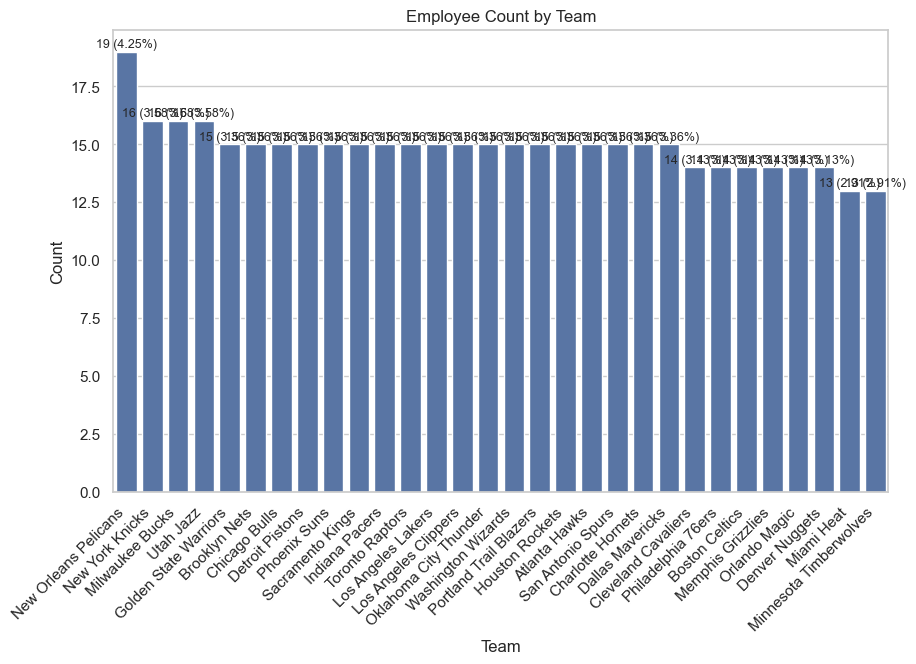

In [19]:
if 'Team' in df.columns:
    team_counts = df['Team'].value_counts().sort_values(ascending=False)
    team_pct = (team_counts / team_counts.sum() * 100).round(2)
    print("Team counts:", team_counts.head(10))
    print("Team % split:", team_pct.head(10))
    
    # Bar plot with percentages annotated
    fig, ax = plt.subplots(figsize=(10,6))
    sns.barplot(x=team_counts.index, y=team_counts.values, ax=ax)
    ax.set_title("Employee Count by Team")
    ax.set_xlabel("Team")
    ax.set_ylabel("Count")
    for i, v in enumerate(team_counts.values):
        ax.text(i, v + max(team_counts.values)*0.01, f"{v} ({team_pct.values[i]}%)", ha='center', fontsize=9)
    plt.xticks(rotation=45, ha='right')
else:
    print("Column 'Team' not found — skipping team distribution.")

# Segregate employees based on their positions (2 marks)

Position counts: Position
SG    99
PF    97
PG    88
SF    84
C     79
Name: count, dtype: int64


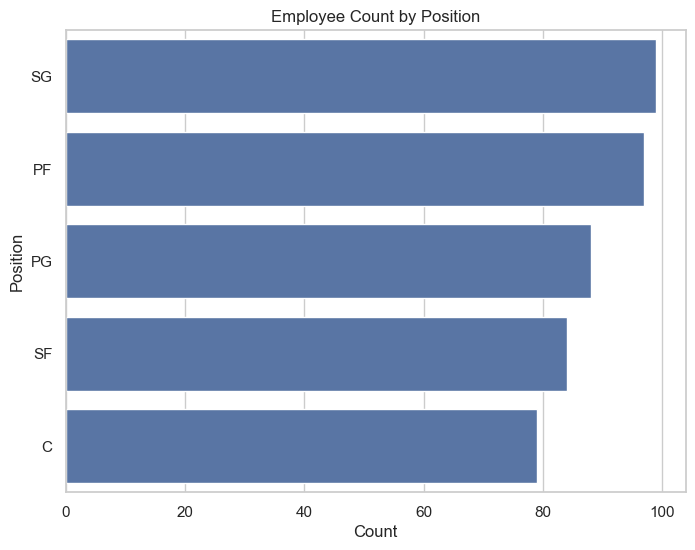

In [21]:
if 'Position' in df.columns:
    pos_counts = df['Position'].value_counts().sort_values(ascending=False)
    print("Position counts:", pos_counts.head(10))
    fig, ax = plt.subplots(figsize=(8,6))
    sns.barplot(y=pos_counts.index, x=pos_counts.values, ax=ax)
    ax.set_title("Employee Count by Position")
    ax.set_xlabel("Count")
    ax.set_ylabel("Position")
else:
    print("Column 'Position' not found — skipping position segregation.")

# Identify predominant age group (2 marks)

Age group counts: AgeGroup
<25      150
25-34    267
35-44     30
45-54      0
55-64      0
65+        0
Name: count, dtype: int64
Predominant age group: 25-34


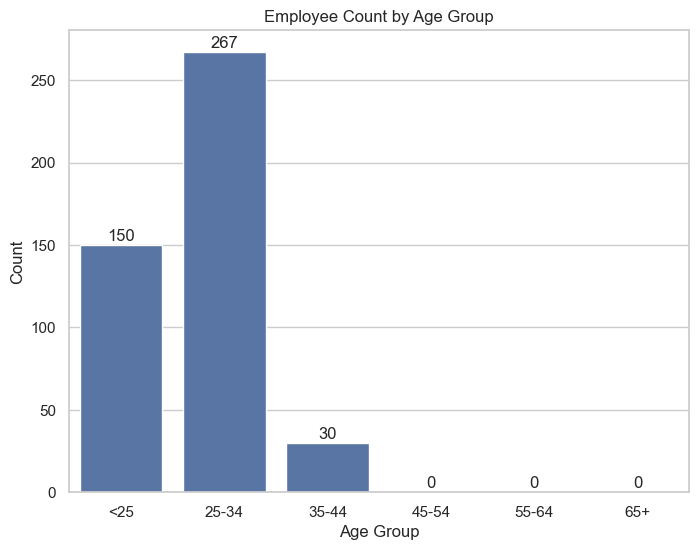

In [23]:
if 'Age' in df.columns:
    bins = [0, 24, 34, 44, 54, 64, 200]
    labels = ['<25','25-34','35-44','45-54','55-64','65+']
    df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)
    agegrp_counts = df['AgeGroup'].value_counts().reindex(labels).fillna(0).astype(int)
    predominant = agegrp_counts.idxmax()
    print("Age group counts:", agegrp_counts)
    print("Predominant age group:", predominant)
    # Plot
    fig, ax = plt.subplots(figsize=(8,6))
    sns.barplot(x=agegrp_counts.index, y=agegrp_counts.values, ax=ax)
    ax.set_title("Employee Count by Age Group")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("Count")
    for i, v in enumerate(agegrp_counts.values):
        ax.text(i, v + max(agegrp_counts.values)*0.01, str(v), ha='center')
else:
    print("Column 'Age' not found — skipping age group analysis.")

# Which team and position have the highest salary expenditure (2 marks)

Top team by total salary expenditure: Cleveland Cavaliers 106988689.0
Top position by total salary expenditure: C 466377332.0


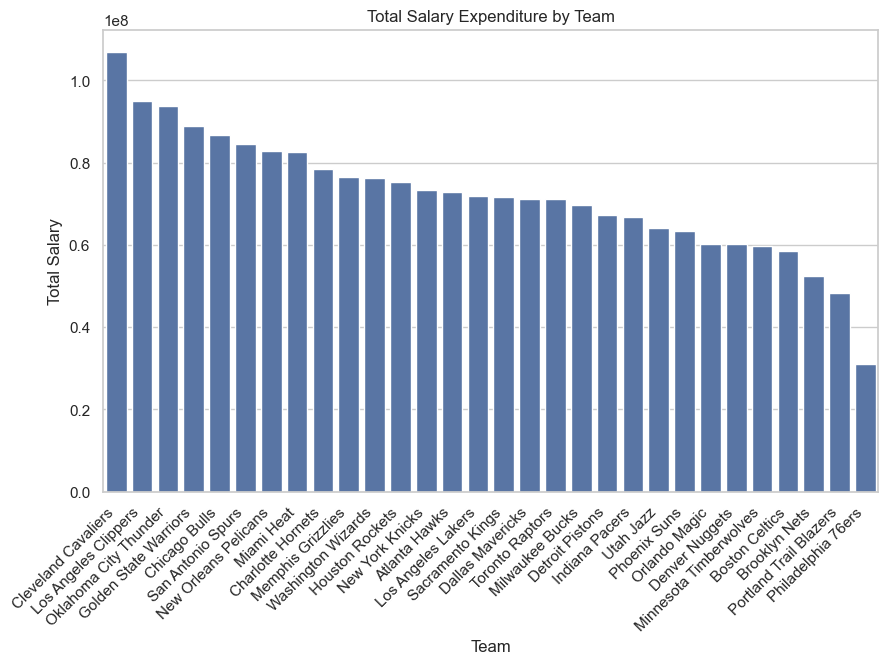

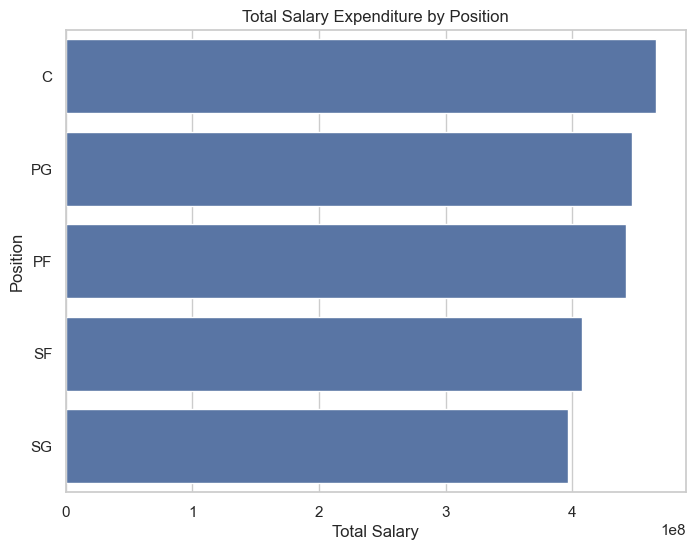

In [24]:
if 'Salary' in df.columns:
    if 'Team' in df.columns:
        team_salary = df.groupby('Team')['Salary'].sum().sort_values(ascending=False)
        top_team = team_salary.idxmax()
        print("Top team by total salary expenditure:", top_team, team_salary.iloc[0])
        fig, ax = plt.subplots(figsize=(10,6))
        sns.barplot(x=team_salary.index, y=team_salary.values, ax=ax)
        ax.set_title("Total Salary Expenditure by Team")
        ax.set_xlabel("Team")
        ax.set_ylabel("Total Salary")
        plt.xticks(rotation=45, ha='right')
    else:
        team_salary = None

    if 'Position' in df.columns:
        pos_salary = df.groupby('Position')['Salary'].sum().sort_values(ascending=False)
        top_position = pos_salary.idxmax()
        print("Top position by total salary expenditure:", top_position, pos_salary.iloc[0])
        fig, ax = plt.subplots(figsize=(8,6))
        sns.barplot(x=pos_salary.values, y=pos_salary.index, ax=ax)
        ax.set_title("Total Salary Expenditure by Position")
        ax.set_xlabel("Total Salary")
        ax.set_ylabel("Position")
    else:
        pos_salary = None
else:
    print("Column 'Salary' not found — skipping salary expenditure analysis.")

# Correlation between age and salary + visual (2 marks)

Pearson correlation between Age and Salary: r = 0.214, p = 4.995e-06


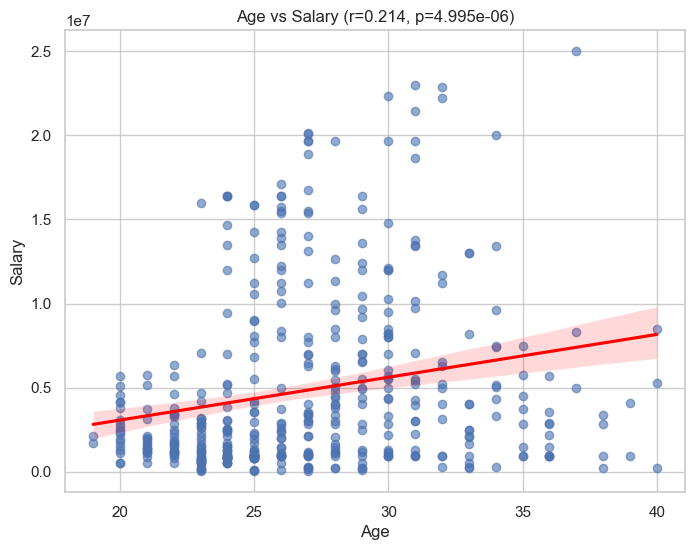

In [26]:
if ('Age' in df.columns) and ('Salary' in df.columns):
    corr_df = df[['Age','Salary']].dropna()
    corr_coef, corr_p = stats.pearsonr(corr_df['Age'], corr_df['Salary'])
    print("Pearson correlation between Age and Salary: r = {:.3f}, p = {:.3e}".format(corr_coef, corr_p))
    # Scatter + regression line
    fig, ax = plt.subplots(figsize=(8,6))
    sns.regplot(x='Age', y='Salary', data=corr_df, ax=ax, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
    ax.set_title(f'Age vs Salary (r={corr_coef:.3f}, p={corr_p:.3e})')
else:
    print("Age or Salary column missing — skipping correlation analysis.")

In [ ]:

insights = []
insights.append("ABC Company — Data Story & Key Insights")
insights.append("--------------------------------------")
insights.append(f"Dataset shape after cleaning: {df.shape}")

if 'Team' in df.columns:
    insights.append("\nTop teams by headcount:")
    insights.append(team_counts.head(10).to_string())
    insights.append("\nTeam percentage split (top 10):")
    insights.append(team_pct.head(10).to_string())

if 'Position' in df.columns:
    insights.append("\nTop positions by headcount:")
    insights.append(pos_counts.head(10).to_string())

if 'AgeGroup' in df.columns:
    insights.append(f"\nPredominant age group: {predominant}")

if ('Salary' in df.columns):
    if team_salary is not None:
        insights.append(f"\nTeam with highest salary expenditure: {team_salary.index[0]} (Total = {team_salary.iloc[0]:,.2f})")
    if pos_salary is not None:
        insights.append(f"\nPosition with highest salary expenditure: {pos_salary.index[0]} (Total = {pos_salary.iloc[0]:,.2f})")
if ('Age' in df.columns) and ('Salary' in df.columns):
    insights.append(f"\nAge-Salary correlation: r = {corr_coef:.3f}, p = {corr_p:.3e}")

insights.append("\nRecommended next steps:")
insights.append("- Investigate reasons behind any high salary concentration in certain teams/positions (hiring senior staff, bonuses, contractors).")
insights.append("- If age and salary correlation is weak, try additional features (experience, education).")
insights.append("- Consider segmentation (e.g., cluster analysis) to find distinct employee groups for tailored HR policies.")

with open("data_story.txt", "w") as f:
    f.write("\n".join(insights))
print("\nSaved data story to data_story.txt")
